In [10]:
import cv2
import matplotlib as mp
import sklearn as sk
import pandas, numpy, glob, matplotlib.pyplot, matplotlib.cbook, matplotlib.image

D:\Magisterka\Semestr 3\Uczenie glebokie L\projekt\Sign Language Detection\dataset_split
Train images path: D:\Magisterka\Semestr 3\Uczenie glebokie L\projekt\Sign Language Detection\dataset_split\images\train
Train labels path: D:\Magisterka\Semestr 3\Uczenie glebokie L\projekt\Sign Language Detection\dataset_split\labels\train
Train images: 87
Created data.yaml:
 
train: D:\Magisterka\Semestr 3\Uczenie glebokie L\projekt\Sign Language Detection\dataset_split\images\train


names:
  0: Yes
  1: No
  2: Hello
  3: I Love You
  4: Thank You

Showing sample: IMG_7273.JPG


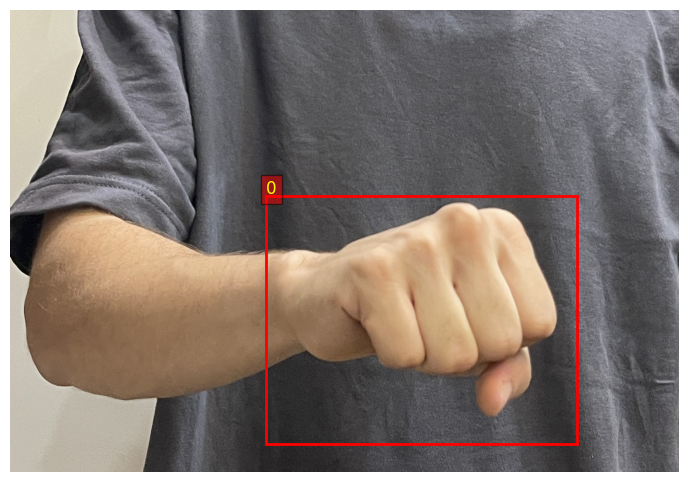

Loading model: yolov8s.pt
Starting training with args: {'data': 'data.yaml', 'epochs': 30, 'imgsz': 640, 'batch': 8, 'workers': 2, 'device': 'cpu', 'patience': 20, 'save': True}
Ultralytics 8.3.235  Python-3.10.7 torch-2.9.1+cpu CPU (AMD Ryzen 7 5800HS with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mos

KeyboardInterrupt: 

In [ ]:
# ---------- 0. Setup ----------
import os
import sys
import glob
import shutil
from pathlib import Path
import random
import time
import json

# ---------- 0.1 Change this path to your dataset root ----------
# Example (Kaggle): "/kaggle/input/cars-detection"
# Example (local/colab): "/content/Cars_Detection"
# DATASET_PATH = "/kaggle/input/sign-language-detection-dataset-5-classes/Sign Language Detection/dataset_split"   # <<-- change if needed
DATASET_PATH = "./Sign Language Detection/dataset_split"
# ---------- 0.2 Install ultralytics if not present (uncomment if needed) ----------

# ---------- 1. Imports ----------
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---------- 2. Basic checks & paths ----------
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."

print(root)

train_images = root / "images" / "train"
train_labels = root / "labels" / "train"

test_images = root / "images" / "test"

print("Train images path:", train_images)
print("Train labels path:", train_labels)


for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))


# ---------- 3. Create data.yaml for YOLOv8 ----------
yaml_content = f"""
train: {train_images}


names:
  0: Yes
  1: No
  2: Hello
  3: I Love You
  4: Thank You
"""
with open(DATASET_PATH + "/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print("Created data.yaml:\n", yaml_content)

# ---------- 4. Quick label sanity check function ----------
def yolo_txt_to_boxes(txt_path, img_w, img_h):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    for line in open(txt_path, "r").read().strip().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, xc, yc, w, h = parts
        cls = int(cls)
        xc, yc, w, h = float(xc), float(yc), float(w), float(h)
        x1 = (xc - w/2) * img_w
        y1 = (yc - h/2) * img_h
        x2 = (xc + w/2) * img_w
        y2 = (yc + h/2) * img_h
        boxes.append([int(x1), int(y1), int(x2), int(y2), cls])
    return boxes

def show_image_with_boxes(img_path, label_path=None, figsize=(10,6)):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h,w = img.shape[:2]
    plt.figure(figsize=figsize)
    plt.imshow(img)
    ax = plt.gca()
    if label_path and os.path.exists(label_path):
        boxes = yolo_txt_to_boxes(label_path, w, h)
        for (x1,y1,x2,y2,cls) in boxes:
            ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, edgecolor='r', facecolor='none', linewidth=2))
            ax.text(x1, y1-6, str(cls), fontsize=12, color='yellow', bbox=dict(facecolor='red', alpha=0.5))
    plt.axis('off')
    plt.show()

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    show_image_with_boxes(sample_img, sample_label)
else:
    print("No images found in train/images.")

# ---------- 5. Train YOLOv8 ----------
# Choose model: "yolov8n.pt" "yolov8s.pt" "yolov8m.pt" ...
# For Kaggle V100 use yolov8s (balance) or yolov8n (faster)
model_name = "yolov8s.pt"

print("Loading model:", model_name)
model = YOLO(model_name)

# Training settings
train_args = dict(
    data="data.yaml",
    epochs=5,
    imgsz=640,
    batch=8,        # adjust based on your GPU memory; Kaggle usually batch 8 works
    workers=2,
    device="cpu",       # change to 0 for GPU, or "cpu" for CPU
    patience=20,
    save=True       # save best weights
)

print("Starting training with args:", train_args)
# run training (this will create runs/train/...)
model.train(**train_args)

# ---------- 6. After training: show best model path ----------
# ultralytics saves to runs/detect/train by default. Let's list
runs = sorted(glob.glob("runs/*"), key=os.path.getmtime, reverse=True)
print("Recent runs folder(s):", runs[:3])

# try to find best.pt
best_pt = None
for root_run in runs:
    candidate = Path(root_run) / "weights" / "best.pt"
    if candidate.exists():
        best_pt = candidate
        break
if best_pt is None:
    # also check typical yolov8 folder
    candidate = Path("runs/detect/train/weights/best.pt")
    if candidate.exists():
        best_pt = candidate

print("Best model:", best_pt)

# ---------- 7. Evaluate / Validate on validation set ----------
print("Running model.val() on best weights (or last if best not found).")
if best_pt:
    eval_model = YOLO(str(best_pt))
else:
    eval_model = model  # fallback to current model object
metrics = eval_model.val()
print("Validation metrics:", metrics)

# ---------- 8. Inference on test set and save predictions ----------
print("Running inference on test images and saving results...")
preds = eval_model.predict(
    source=str(test_images),
    conf=0.35,   # confidence threshold
    iou=0.45,
    save=True,   # save annotated images
    save_txt=True, # save predicted .txt in YOLO format
)

print("Predictions done. Check runs/detect/predict or runs/detect/predictN folders.")

# ---------- 9. Visualize predictions for a random test image ----------
test_list = list(test_images.glob("*.*"))
if test_list:
    pick = random.choice(test_list)
    print("Visualizing predictions for:", pick.name)
    res = eval_model.predict(source=str(pick), conf=0.35)
    # ultralytics result can be plotted
    res[0].plot(show=True)  # will display in notebook
else:
    print("No test images found.")

# ---------- 10. Export model (optional) ----------
export_formats = ["onnx", "torchscript"]  # add "engine" for tensorrt if available
for fmt in export_formats:
    try:
        print("Exporting to format:", fmt)
        eval_model.export(format=fmt)
    except Exception as e:
        print("Export failed for", fmt, "->", e)

# ---------- 11. Save inference script snippet (predict_single.py) ----------
inference_script = r'''
"""
predict_single.py
Simple inference script using ultralytics YOLOv8
python predict_single.py --model runs/detect/train/weights/best.pt --image /path/to/img.jpg
"""
import argparse
from ultralytics import YOLO
from pathlib import Path

parser = argparse.ArgumentParser()
parser.add_argument("--model", required=True)
parser.add_argument("--image", required=True)
parser.add_argument("--conf", type=float, default=0.35)
args = parser.parse_args()

model = YOLO(args.model)
res = model.predict(source=args.image, conf=args.conf, save=True)
print("Saved predictions to runs/detect/predict/")
'''
with open("predict_single.py", "w") as f:
    f.write(inference_script)
print("Wrote predict_single.py")